In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configura el formato de visualización para los números flotantes
pd.options.display.float_format = '{:,.2f}'.format

In [10]:
# Construye la ruta de acceso al archivo
ruta_base = r"C:\Users\patri\Downloads"
ruta_archivo = os.path.join(ruta_base, "housing.csv")

# Carga el archivo en un DataFrame
df = pd.read_csv(ruta_archivo, encoding='latin1')

# Diagnostica la estructura de los datos recién cargados
print(df.head())
print(df.columns.tolist())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwate

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
              price      area  bedrooms  bathrooms  stories  parking
count        545.00    545.00    545.00     545.00   545.00   545.00
mean   4,76

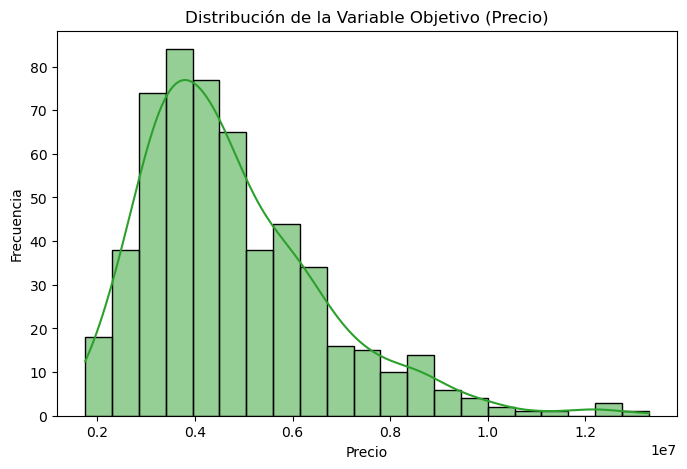

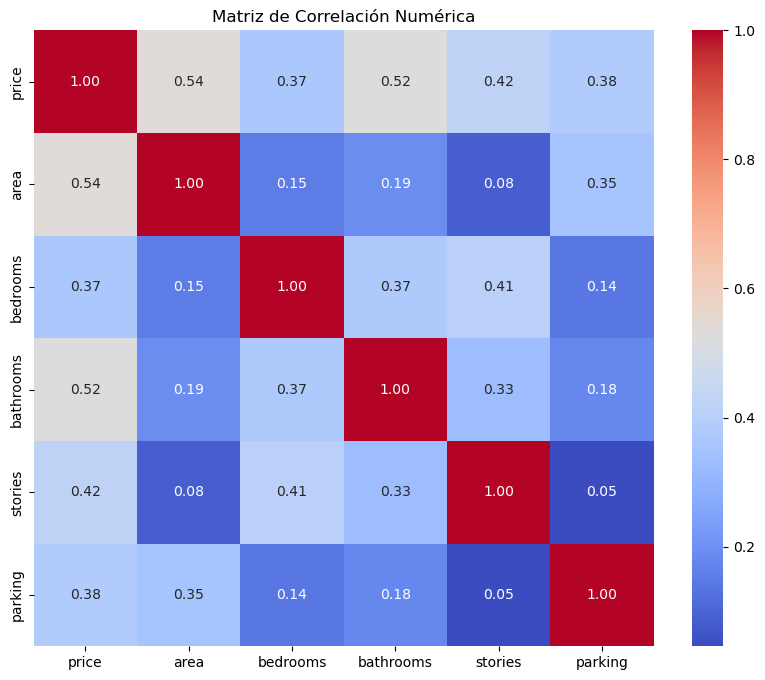

In [11]:
# Muestra información general y conteo de valores no nulos
print(df.info())

# Genera estadísticas descriptivas de las variables numéricas
print(df.describe())

# Visualiza la distribución de la variable objetivo
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='#2ca02c')
plt.title('Distribución de la Variable Objetivo (Precio)')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

# Extrae las variables numéricas y genera una matriz de correlación
columnas_numericas = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(columnas_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación Numérica')
plt.show()

In [12]:
# Define las variables categóricas identificadas en el EDA
columnas_categoricas = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                        'airconditioning', 'prefarea', 'furnishingstatus']

# Genera las variables dummy eliminando la primera categoría para evitar multicolinealidad
df_procesado = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# Separa los datos independientes (X) de la variable dependiente (y)
X = df_procesado.drop('price', axis=1)
y = df_procesado['price']

# Ajusta las variables numéricas a media 0 y desviación estándar 1
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Muestra el resultado final de los datos listos para el entrenamiento
print(X_scaled.head())

   area  bedrooms  bathrooms  stories  parking  mainroad_yes  guestroom_yes  \
0  1.05      1.40       1.42     1.38     1.52          0.41          -0.47   
1  1.76      1.40       5.41     2.53     2.68          0.41          -0.47   
2  2.22      0.05       1.42     0.22     1.52          0.41          -0.47   
3  1.08      1.40       1.42     0.22     2.68          0.41          -0.47   
4  1.05      1.40      -0.57     0.22     1.52          0.41           2.15   

   basement_yes  hotwaterheating_yes  airconditioning_yes  prefarea_yes  \
0         -0.73                -0.22                 1.47          1.80   
1         -0.73                -0.22                 1.47         -0.55   
2          1.36                -0.22                -0.68          1.80   
3          1.36                -0.22                 1.47          1.80   
4          1.36                -0.22                 1.47         -0.55   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0      

In [13]:
# Divide la muestra en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Instancia el modelo y lo entrena con los datos
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Realiza las predicciones sobre el conjunto de prueba
y_pred = modelo_lr.predict(X_test)

# Calcula las métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Evaluación del Modelo ---")
print(f"R2 Score: {r2:.4f} (El modelo explica el {r2*100:.2f}% de la varianza del precio)")
print(f"Error Absoluto Medio (MAE): {mae:,.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:,.2f}")

--- Evaluación del Modelo ---
R2 Score: 0.6529 (El modelo explica el 65.29% de la varianza del precio)
Error Absoluto Medio (MAE): 970,043.40
Raíz del Error Cuadrático Medio (RMSE): 1,324,506.96


--- Top 5 Variables Más Importantes ---
               Variable  Coeficiente
2             bathrooms   549,420.50
0                  area   511,615.56
9   airconditioning_yes   367,817.89
3               stories   353,158.43
10         prefarea_yes   267,018.66


C:\Users\patri\AppData\Local\Temp\ipykernel_30316\178194590.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=importancia_vars.head(10), palette='viridis')


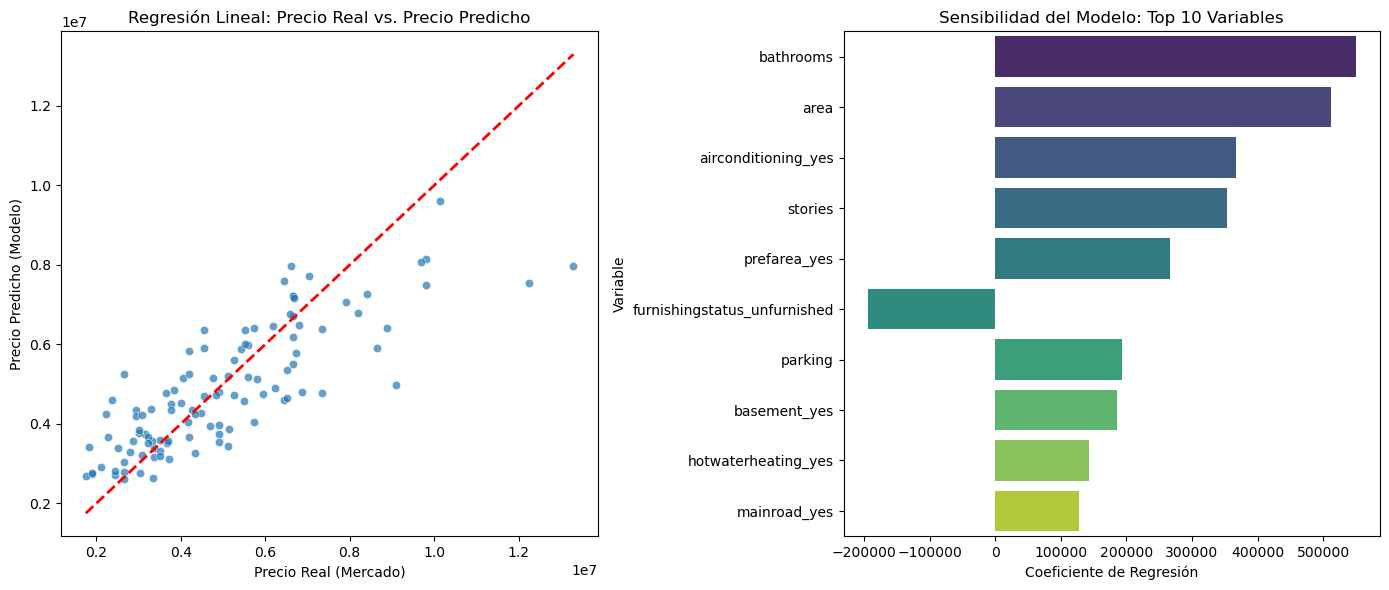

In [15]:
# Extrae los coeficientes para el análisis de sensibilidad
importancia_vars = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_lr.coef_
})

# Ordena las variables por su impacto absoluto
importancia_vars['Impacto_Absoluto'] = importancia_vars['Coeficiente'].abs()
importancia_vars = importancia_vars.sort_values(by='Impacto_Absoluto', ascending=False)

print("--- Top 5 Variables Más Importantes ---")
print(importancia_vars[['Variable', 'Coeficiente']].head())

# Configura el lienzo para las gráficas finales
plt.figure(figsize=(14, 6))

# Subtrama 1: Gráfico de Dispersión (Real vs Predicción)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='#1f77b4')
# Traza la línea de referencia perfecta
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('Regresión Lineal: Precio Real vs. Precio Predicho')
plt.xlabel('Precio Real (Mercado)')
plt.ylabel('Precio Predicho (Modelo)')

# Subtrama 2: Gráfico de Barras (Importancia de Variables)
plt.subplot(1, 2, 2)
sns.barplot(x='Coeficiente', y='Variable', data=importancia_vars.head(10), palette='viridis')
plt.title('Sensibilidad del Modelo: Top 10 Variables')
plt.xlabel('Coeficiente de Regresión')
plt.ylabel('Variable')

# Muestra las visualizaciones estructuradas
plt.tight_layout()
plt.show()